**Exp 8**  -
**Association Rule Learning** **(Apriori Algorithm)** **and**
**Dimensionality Reduction (PCA)**

Name: Priyadharshini B

Roll no: 24BAD093

Scenario 1 - ASSOCIATION RULE MINING USING APRIORI ALGORITHM

Dataset Sample:
   Member_number        Date   itemDescription
0           1808  21-07-2015    tropical fruit
1           2552  05-01-2015        whole milk
2           2300  19-09-2015         pip fruit
3           1187  12-12-2015  other vegetables
4           3037  01-02-2015        whole milk

Sample Transactions:
[['sausage', 'whole milk', 'semi-finished bread', 'yogurt'], ['whole milk', 'pastry', 'salty snack'], ['canned beer', 'misc. beverages'], ['sausage', 'hygiene articles'], ['soda', 'pickled vegetables']]

Encoded Data:
   Instant food products  UHT-milk  abrasive cleaner  artif. sweetener  \
0                  False     False             False             False   
1                  False     False             False             False   
2                  False     False             False             False   
3                  False     False             False             False   
4                  False     False             False             False   

   baby cosmetics

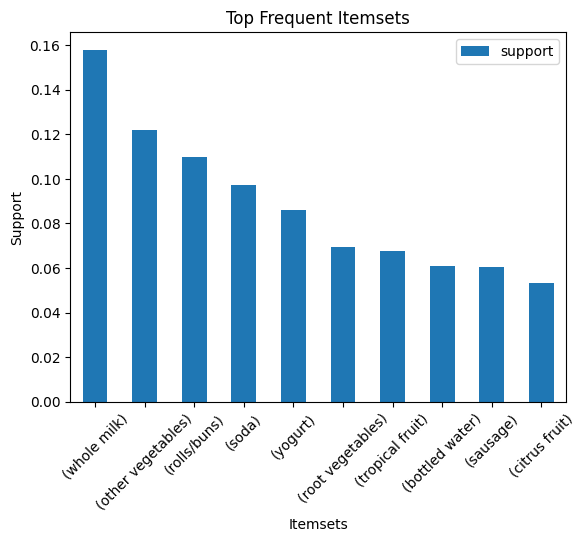

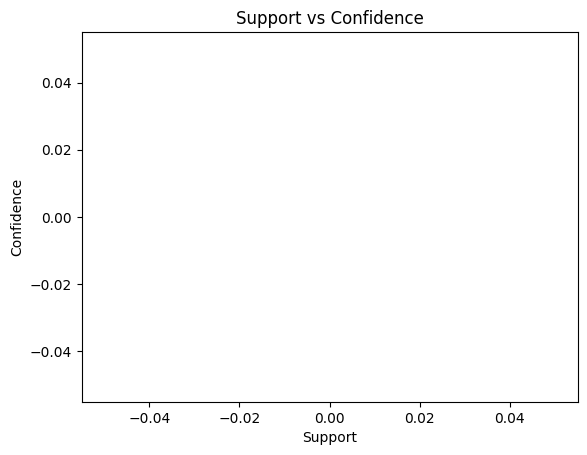

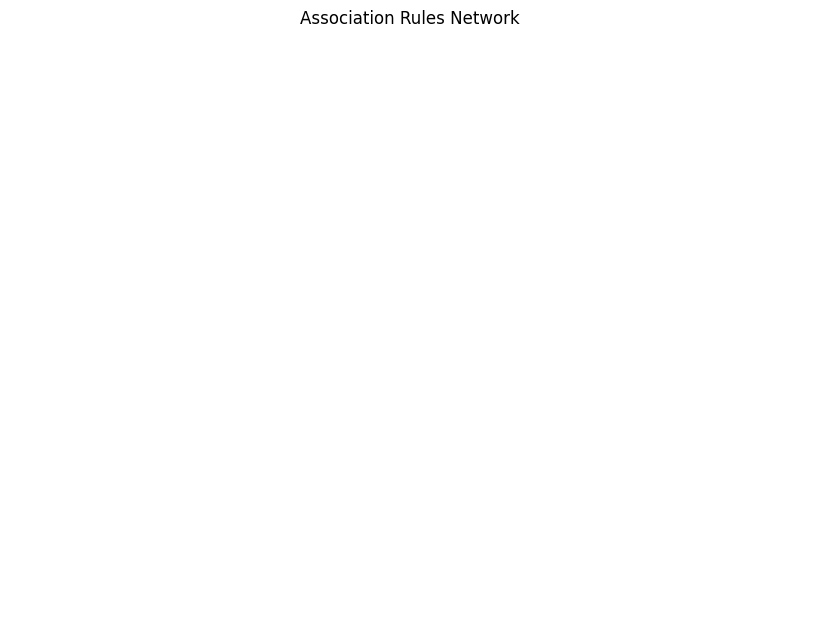

In [9]:

# Import libraries
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
import matplotlib.pyplot as plt
import networkx as nx

# Load dataset
df = pd.read_csv("/content/Groceries_dataset.csv (1).zip")

print("Dataset Sample:")
print(df.head())

# Convert to transactions
transactions = df.groupby(['Member_number', 'Date'])['itemDescription'].apply(list).tolist()

print("\nSample Transactions:")
print(transactions[:5])

# One-hot encoding
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
df_encoded = pd.DataFrame(te_array, columns=te.columns_)

print("\nEncoded Data:")
print(df_encoded.head())

# Apply Apriori
frequent_itemsets = apriori(df_encoded, min_support=0.005, use_colnames=True)

print("\nFrequent Itemsets:")
print(frequent_itemsets.head())

# Generate rules
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.2)

print("\nAssociation Rules:")
print(rules[['antecedents','consequents','support','confidence','lift']].head())

print("\nNumber of Rules:", len(rules))

# Filter strong rules
strong_rules = rules[(rules['confidence'] > 0.5) & (rules['lift'] > 1)]

print("\nStrong Rules:")
print(strong_rules[['antecedents','consequents','support','confidence','lift']].head())

# Analysis
print("\nSupport Analysis:")
for s in [0.005, 0.01, 0.02]:
    itemsets = apriori(df_encoded, min_support=s, use_colnames=True)
    print("Support =", s, "Itemsets =", len(itemsets))

print("\nConfidence Analysis:")
rules_low = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.2)
rules_high = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.6)

print("Low confidence rules:", len(rules_low))
print("High confidence rules:", len(rules_high))

# Interpretation
print("\nSample Interpretations:")
for i, row in strong_rules.head(5).iterrows():
    print("If", list(row['antecedents']), "then", list(row['consequents']))

# Bar chart
top_itemsets = frequent_itemsets.sort_values(by="support", ascending=False).head(10)
top_itemsets.plot(x='itemsets', y='support', kind='bar')
plt.xlabel("Itemsets")
plt.ylabel("Support")
plt.title("Top Frequent Itemsets")
plt.xticks(rotation=45)
plt.show()

# Scatter plot
plt.scatter(rules['support'], rules['confidence'])
plt.xlabel("Support")
plt.ylabel("Confidence")
plt.title("Support vs Confidence")
plt.show()

# Network graph
G = nx.DiGraph()
for i, row in strong_rules.head(10).iterrows():
    G.add_edge(str(list(row['antecedents'])), str(list(row['consequents'])))

plt.figure(figsize=(8,6))
nx.draw(G, with_labels=True)
plt.title("Association Rules Network")
plt.show()

Scenario 2 - DIMENSIONALITY REDUCTION USING PCA

Original Data:
    sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

Explained Variance Ratio:
 [0.72962445 0.22850762 0.03668922 0.00517871]

Cumulative Variance:
 [0.72962445 0.95813207 0.99482129 1.        ]

Reduced Data:
         PC1       PC2
0 -2.264703  0.480027
1 -2.080961 -0.674134
2 -2.364229 -0.341908
3 -2.299384 -0.597395
4 -2.389842  0.646835
Components: 1, Cumulative Variance: 0.7296244541329993
Components: 2, Cumulative Variance: 0.9581320720000163
Components: 3, Cumulative Variance: 0.994821290892845
Components: 4, Cumulative Variance: 0.9999999999999999


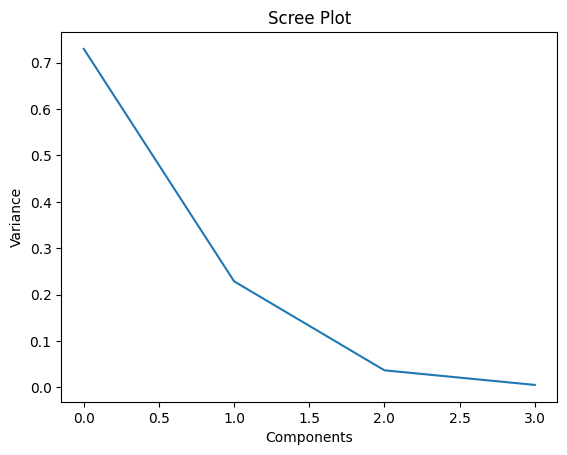

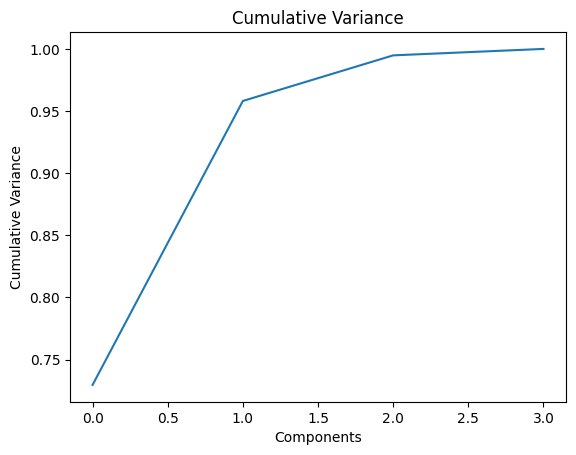

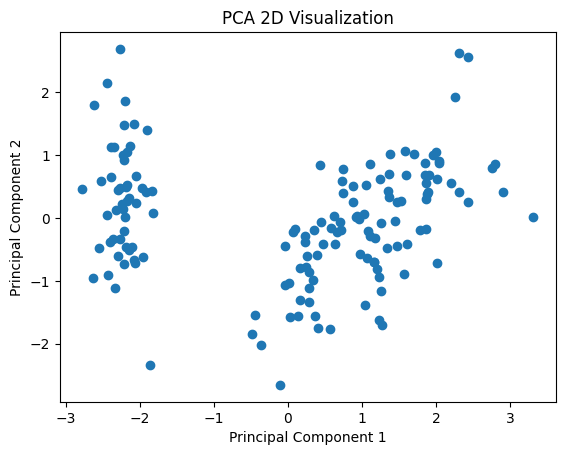

In [3]:
# Remove warnings
import warnings
warnings.filterwarnings("ignore")

# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Load dataset
data = load_iris()
df = pd.DataFrame(data.data, columns=data.feature_names)

print("Original Data:\n", df.head())

# 2. Data preprocessing
# Handle missing values (if any)
df = df.dropna()

# 3. Standardize features
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

# 4. Apply PCA
pca = PCA()
principal_components = pca.fit_transform(scaled_data)

# 5. Explained variance
explained_variance = pca.explained_variance_ratio_
print("\nExplained Variance Ratio:\n", explained_variance)

# 6. Cumulative variance
cumulative_variance = explained_variance.cumsum()
print("\nCumulative Variance:\n", cumulative_variance)

# 7. Reduce dimensions (2D)
pca_2 = PCA(n_components=2)
reduced_data = pca_2.fit_transform(scaled_data)

pca_df = pd.DataFrame(reduced_data, columns=['PC1', 'PC2'])

print("\nReduced Data:\n", pca_df.head())

# ANALYSIS TASKS
# Decide optimal number of components
for i, var in enumerate(cumulative_variance):
    print(f"Components: {i+1}, Cumulative Variance: {var}")


# VISUALIZATION
# 1. Scree plot
plt.plot(explained_variance)
plt.xlabel("Components")
plt.ylabel("Variance")
plt.title("Scree Plot")
plt.show()

# 2. Cumulative variance graph
plt.plot(cumulative_variance)
plt.xlabel("Components")
plt.ylabel("Cumulative Variance")
plt.title("Cumulative Variance")
plt.show()

# 3. 2D Scatter plot
plt.scatter(pca_df['PC1'], pca_df['PC2'])
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA 2D Visualization")
plt.show()